# Produce dirty image and psf, from a (rascil) FITS image, and an instrumental setup (baselines, frequencies, etc.)

In [17]:
import matplotlib.pyplot as plt
import matplotlib
import numpy

from astropy.coordinates import SkyCoord
import astropy.units as u

from rascil.processing_components import plot_uvcoverage, plot_visibility

from radioimaging.util import util
from radioimaging.visibility import vissim, residual, weights
from radioimaging.images import images

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [5, 5]

### Generate visibilities based on antenna configuration, integration time, hour angle interval of observations, phase centre, frequencies etc.

In [18]:
gt_name = "../data/SGRA_full_gt.fits"
config_name = "MID"

phasecentre = SkyCoord(ra=+56.0 * u.deg, dec=-15.0 * u.deg, frame='icrs', equinox='J2000')
ha_interval=(-2,2)

bandwidth = 1e4
frequencies = range(int(1e9), int(1e9 + bandwidth*1), int(bandwidth))
bandwidths = [bandwidth] * len(frequencies)

vt = vissim.generate_visibilities(phasecentre,ha_interval,tel=config_name, integration_time=30, frequencies=numpy.array(frequencies).astype(float), channel_bandwidths=numpy.array(bandwidths))

### Plot uv coverage (if there aren't too many visibilities, otherwise this function takes too long and may crash)

There is no flagged visibility. Skip plotting flagged.
/home/sunwang/radio-imaging/environment/radioimaging/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


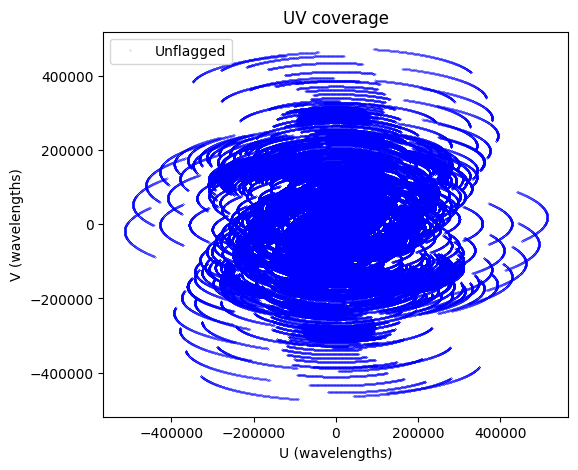

In [19]:
if vt.vis.size < 1e8:
    matplotlib.rcParams['figure.figsize'] = [6, 5]
    plot_uvcoverage([vt])


### Fill visibilities amplitude from (Fourier plane values) of image in FITS file. Cell size corresponds to the (advised) pixel angular size in radians. Uses Nifty gridder.

In [20]:
num_pix = util.fromfits(gt_name).shape[0]
vt, cell_size, im = residual.visibilities_from_image(vt, gt_name,return_cellsize=True,return_image=True,scale_factor=1.8)
print(cell_size)

8.755170341876385e-07


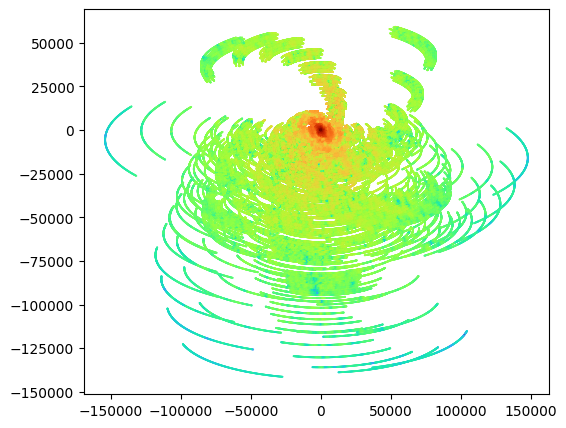

In [21]:
u = vt.visibility_acc.u.data.flatten()
v = vt.visibility_acc.v.data.flatten()
amp = numpy.log(numpy.abs(vt.vis.data).flatten())

plt.scatter(u, v, s=0.1, c=amp, cmap=cmap)
plt.show()

### Add artificial noise, this is currently based on the source but an option should be added for it to be based on the sensitivity (https://www.skao.int/en/science-users/ska-tools/493/ska-sensitivity-calculators)

In [5]:
percentage = 0.02

stdv_real = numpy.std(numpy.array(vt.vis.real).flatten())
stdv_imag = numpy.std(numpy.array(vt.vis.imag).flatten())

stdv_real *= percentage
stdv_imag *= percentage

noise_real = numpy.random.normal(loc=0, scale=stdv_real, size=vt.vis.shape)
noise_imag = numpy.random.normal(loc=0, scale=stdv_imag, size=vt.vis.shape) 

noise = numpy.vectorize(complex)(noise_real, noise_imag)
vt["vis"].data = vt.vis + noise

### Visualize dirty and psf and their Fourier transforms

Model image plate scale (arcsec) is 1.805884e-01


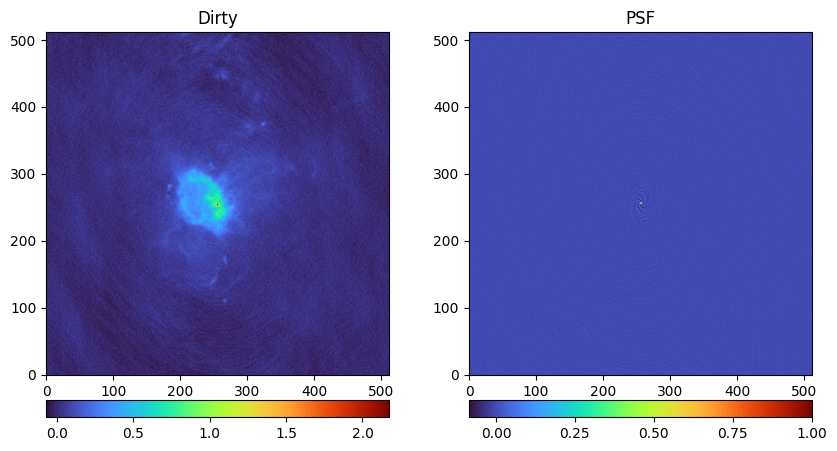

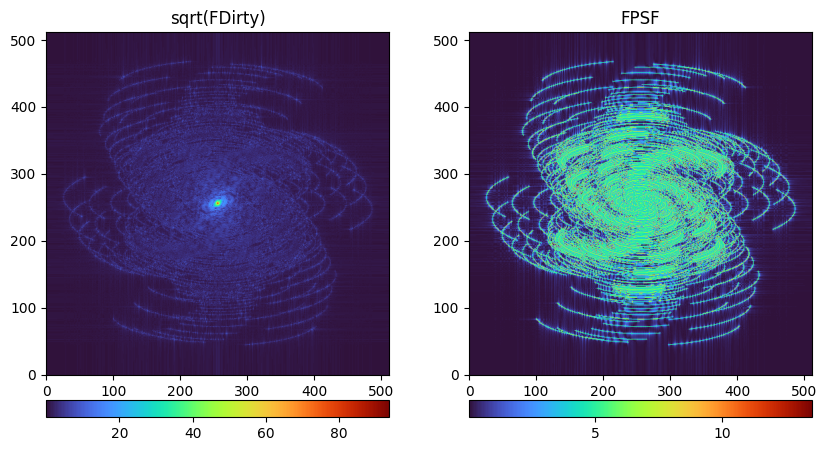

In [6]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

dirty, psf = residual.dirty_psf_from_visibilities(vt,cell_size,npix=num_pix,weighting="uniform", override_cellsize=False)
util.plotNImages([dirty.pixels.data[0,0,:,:], psf.pixels.data[0, 0,:,:]], ["Dirty", "PSF"], cmap=cmap)

fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(dirty.pixels.data[0,0,:,:]))))
fpsf = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(psf.pixels.data[0,0,:,:]))))
util.plotNImages([fdirty ** 0.5, fpsf], ["sqrt(FDirty)", "FPSF"], cmap="turbo")

### Plot visibility amplitudes as a function of uv radius

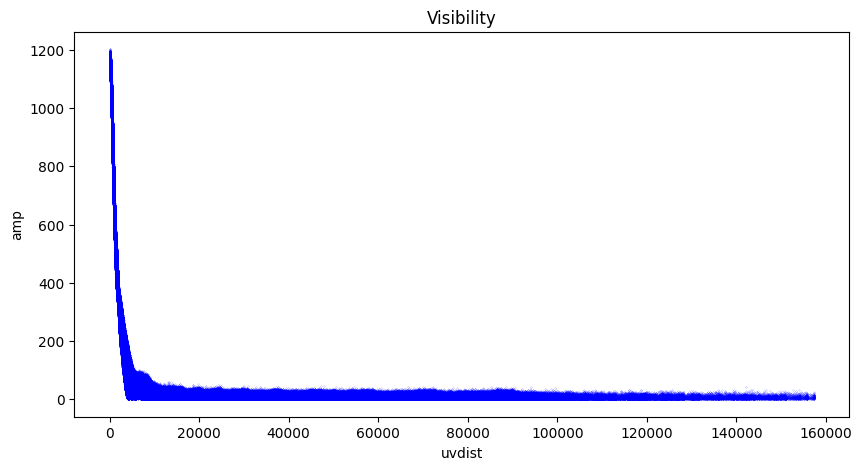

In [7]:
#vv = np.ones(vt.vis.shape)
#vt["vis"].data = vv
import math
plot_visibility([vt])
u = vt.visibility_acc.u.data
v = vt.visibility_acc.v.data

max_dist = 0

uv=numpy.array(vt.visibility_acc.uvw_lambda[...,0:2])
nrows,nbaselines, _ = vt.uvw.shape
uv = uv.reshape(nrows*nbaselines*len(frequencies),2)

max_dist = 0
c = numpy.zeros(nrows*nbaselines*len(frequencies))
for i, uval in enumerate(uv):
    c[i] = math.sqrt(uval[0] ** 2 + uval[1] ** 2)
    
nfreq = len(frequencies)

c = numpy.zeros((nrows, nbaselines, nfreq))
for i in range(nbaselines):
    c[:,i,:] = float(i) / nbaselines
c = numpy.imag(vt.vis.data)


### Export visibility data to measurement set file

In [10]:
from rascil.processing_components import export_visibility_to_ms

full_ms_name = '../data8/MID_notaveraged_full.ms'
export_visibility_to_ms(full_ms_name,[vt])

print("done")

../data8/MID_notaveraged_full.ms
done
